#### Global Variables

In [17]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from IPython.display import clear_output
from carousel import Carousel

CATEGORICAL_COLUMNS = [
    'Attrition',
    'BusinessTravel',
    'Department',
    'Gender',
    'JobRole',
    'OverTime',
    'EmployeeName',
    'Prediction'
]

#### Data Validation Functions

In [18]:
def is_empty_line(row):
    '''
    (CHECK FUNCTION): Check if a line is empty or just whitespace.
    Inputs: list - list representing a row from a dataset
    Returns: bool - whether the row was completely empty
    '''
    return row.strip() == ""

In [19]:
def has_correct_fields(row, headers):
    '''
    (CHECK FUNCTION): Check if the row has the same number of fields as the headers.
    Inputs: 
        list - the row we are comparing
        list - the headers we are comparing
    
    Returns: bool - Whether the number of things in the row matches the number of headers
    '''
    return len(row) == len(headers)

#### Import CSV

In [20]:
def import_csv(filename):
    """
    Imports the csv file chosen
    Inputs: str - the filename that should be opened
    Returns: dict - dictionary where each column header is a key
    """

    #Dictionary to hold the data we import
    data_dict = {}


    #open the file safely
    with open(filename, "r") as f:
        content = f.read()
        rows = content.splitlines()

        #Get the headers from the file and put them as keys in the dictionary
        headers = rows.pop(0).split(',')

        #Process each row of data
        for row in rows:
            #Checks if the line is empty
            if not is_empty_line(row):
                #makes each row into a list
                row = row.split(',')

                #Check if we have the correct amount of columns in each row
                if has_correct_fields(row, headers):

                    for i in range(len(headers)):
                        #strip any whitespace from headers and data
                        headers[i] = headers[i].strip()
                        row[i] = row[i].strip()

                        #if the header is not already a key, add it with the first value
                        #If the key already exists, append the new value to the list
                        if headers[i] not in data_dict:
                            data_dict[headers[i]] = [row[i]]
                        else:
                            for key, values in data_dict.items():
                                if key == headers[i]:
                                    values.append(row[i])
                
            #Print error messages and stop the program if it fails a test
                else:
                    raise Exception('Error. Incorrect number of columns in row')
                    
            else:
                raise Exception('Error, a line in the program is empty')
                


    return data_dict

#### Accessor Functions

In [21]:
class Accessor:
    """An instance of this class reprsents the ability access values from a dataset"""
    def __init__(self, aDict):
        if type(aDict) == dict:
            self.dict = aDict
        else:
            raise Exception("Error: Input must be a dictionary")
        
    def get_value(self, col, i):
        """
        This Function takes in a column name and returns the value at the specified index from that column
        Inputs: str - col: the column name
        Returns: list - data: the values associated with the column name
        """
        if col in self.dict.keys():
            return self.dict[col][i]
        else:
            raise Exception("Column name does not exist")
        
    def convert_to_rows(self, cols):
        """
        This function takes the columns provided and converts them to rows
        Inputs: dict - cols: a dictionary of the columns that we want to convert to rows. Each key is the header and each value is a list of values that are in the column
        Returns: list - a list of lists, where each inner list is a row
        """
        if type(cols) == dict:
            headers = []
            values = []

            for key, value in cols.items():
                headers.append(key)
                values.append(value)

            rows = list(zip(*values))

            #Get the values into a list of lists instead of a list of tuples, for more versatility
            array = []
            for row in rows:
                inner_array = []
                for value in row:
                    inner_array.append(value)
                array.append(inner_array)  

            return array

        else:
            raise Exception("Error: Input must be a dictionary")
        



    def count_values(self, col):
        """
        This function counts the number of occurances for each unique value in a column
        Inputs: str - col: column name
        Returns: dict - Each key is a unique value and each value is the number of occurances
        """
        count = {}

        if col in self.dict.keys():
            unique_values = set(self.dict[col])
            unique_values = list(unique_values)

            for unique in unique_values:
                for value in self.dict[col]:
                    if value == unique:
                        if unique not in count.keys():
                            count[unique] = 1
                        else:
                            count[unique] += 1

            return count
        else:
            raise Exception("Column name does not exist")
        
    


## Section A

### CODE:

In [22]:
class Clean:
    """An instance of this class helps clean data from a csv"""
    def __init__(self, aDict):
        if type(aDict) == dict:
            self.dict = aDict
        else:
            raise Exception('Data must be in a dictionary format')
        
    def convert_to_num(self, value):
        '''
        (CLEANING FUNCTION): Try to convert a string to a numerical value
        Inputs: str - the value we are trying to convert
        Returns: int or float or str - the value converted to a number if possible, otherwise the original string
        '''
        try:
            return int(value)
        except ValueError:
            try:
                return float(value)
            except ValueError:
                return value
    
    def convert_column_to_num(self):
        '''
        (CLEANING FUNCTION): Try to convert the values in a column to numerical values
        Inputs: dict - the dataset we are trying to convert
        Returns: dict - the dataset with the values in the column converted to numbers if possible, otherwise the original string
        '''
        keys = self.dict.keys()
        for key in keys:
            col_list = []
            #Convert each value in the column to float if possible. If not, keep them the same
            for value in self.dict[key]:
                new_value = self.convert_to_num(value)
                col_list.append(new_value)

            self.dict[key] = col_list
        
    
    def cols_with_missing_data(self):
        '''
        (CLEANING FUNCTION): Check which columns have missing data
        Inputs: dict - the dataset we are trying to check
        Returns: dict - a dict of the columns that have missing data, and the amount of values they have that are missing
        '''

        missing_data_dict = {}
        keys = self.dict.keys()
        for key in keys:
            count = 0
            for value in self.dict[key]:
                if value == "":
                    count += 1
            if count > 0:
                missing_data_dict[key] = count
        return missing_data_dict
    
    def confirm_cleaned(self, clean_dict):
        '''
        (CLEANING FUNCTION): Check if there is any missing data in the dataset
        Inputs: dict - the dataset we are trying to check
        Returns: bool - whether there is any missing data in the dataset
        '''
        clean = True
        for key, value in clean_dict.items():
            for item in value:
                if item == "":
                    clean = False
        return clean
    
    def remove_rows_with_missing_data(self):
        '''
        (CLEANING FUNCTION): 
        If a column is a categorical variable, and if the value is missing, remove the row 
        If a column is a numerical/ordinal variable, and the value is missing, replace it with the average of the column
        Inputs: dict - the dataset we are checking for missing data
        Returns: 
            dict - the cleaned dataset with missing data removed or replaced
            int - initial number of rows

        '''


        indices_to_remove = []
        clean_dict = {}
        for key, value in self.dict.items():
            clean_dict[key] = value.copy()

        for header, data in clean_dict.items():

            #Loop through the columns and check for missing values in the categorical columns. If we find a missing value, we append its index to a list of indices to remove
            if header in CATEGORICAL_COLUMNS:
                for i in range(len(data)):
                    if data[i] == "":
                        indices_to_remove.append(i)
            
            #Loop through the columns and check for missing values in the numerical columns. If we find a missing value, we replace it with the average of the column
            else:
                nums_to_avg = []
                for i in range(len(data)):
                    if data[i] != "":
                        nums_to_avg.append(data[i])
                avg = sum(nums_to_avg) / len(nums_to_avg)

                for i in range(len(data)):
                    if data[i] == "":
                        data[i] = avg
            
        #Ensure there are no duplicate indices to remove 
        indices_to_remove = list(set(indices_to_remove))
        #Put indices in reverse order to ensure we remove the correct rows without messing up the indices as we go
        indices_to_remove = sorted(indices_to_remove, reverse=True)

        #Remove the rows with missing data
        for index in indices_to_remove:
            for key, values in clean_dict.items():
                values.pop(index)

                        
        return clean_dict
    
    def compare_datasets(self, dict2):
        '''
        (CLEANING FUNCTION): Compare two datasets to see if they are the same
        Inputs: 
            dict1 - the bigger dataset (self.dict)
            dict2 - the smaller dataset that should be a cleaned version of the bigger dataset
        
        Returns:
            int - initial number of rows in the dataset
            int - Number of rows removed from the dataset
            int- Number of remaining rows
        '''
        if type(dict2) == dict:
            keys = []
            for key in self.dict.keys():
                keys.append(key)
            length1 = len(self.dict[keys[0]])
            length2 = len(dict2[keys[0]])
            difference = length1 - length2
            return length1, difference, length2
        else:
            raise Exception('Compared Data must be a dictionary')
        
    def display_cleaning_report(self, cols_missing, initial_rows, removed_rows, remaining_rows, is_clean):
        '''
        (CLEANING FUNCTION): Display a report of the cleaning process
        Inputs:
            dict - the columns with missing data and the amount of missing data in each column
            int - initial number of rows in the dataset
            int - number of rows removed from the dataset
            int - number of remaining rows in the dataset
            bool - whether the cleaned dataset is clean or not
        Returns: None
        '''
        print(f"Initial number of rows: {initial_rows}")
        for key, value in cols_missing.items():
            if key in CATEGORICAL_COLUMNS:
                print(f"{key}: {value} values missing (rows removed)")
            else:
                print(f"{key}: {value} values missing (imputed)")
        print(f"Rows removed due to categorical missing values: {removed_rows}")
        print(f"Remaining number of rows: {remaining_rows}")
        print()

        if is_clean:
            print("Confirmed: No missing values remain in the dataset.")
        else:
            raise Exception("Error: Missing values still remain in the dataset.")
        
    def run_clean(self):
        """
        This function uses the above functions to run the cleaning process and clean the dictionary provided
        Inputs: None
        Returns: None
        """
         #Convert values to numbers if possible. Do it twice to ensure all floats are converted to integers if possible
        self.convert_column_to_num()
        self.convert_column_to_num()

        #Remove any missing data from the dataset
        clean_dict = self.remove_rows_with_missing_data()

        return clean_dict
        

In [23]:
class Attrition:
    """An instance of this class reprsents the analysis of attrition"""
    def __init__(self, aDict):
        if type(aDict) == dict:
            self.dict = aDict
        else:
            raise Exception("Error: Input must be a dictionary")
        
        self.accessor = Accessor(self.dict)
        
    def distribution_by_age(self, col):
        """
        Groups employees into 10 year age buckets and separates them into yes attrtion and no attrition
        Inputs: Column name of the yes/no column that we are getting the distribution on
        Returns: 
            yes_dict - holds the age buckets and the number of people who were yes attrition
            no_dict - holds the age buckets and the number of people who were no attriton
        """
        yes_dict = {
            '<20': 0,
            '20-29': 0,
            '30-39': 0,
            '40-49': 0,
            '50-59': 0,
            '60+': 0
        }
        no_dict = {
            '<20': 0,
            '20-29': 0,
            '30-39': 0,
            '40-49': 0,
            '50-59': 0,
            '60+': 0
        }

        if 'Age' in self.dict and col in self.dict:
            for i, value in enumerate(self.dict['Age']):
                outcome = self.accessor.get_value(col, i) #Gets the value that is associated at the same index in a different column of the dictionary

                if outcome == 'Yes':
                    if value < 20:
                        yes_dict['<20'] += 1
                    elif value < 30:
                        yes_dict['20-29'] += 1
                    elif value < 40:
                        yes_dict['30-39'] += 1
                    elif value < 50:
                        yes_dict['40-49'] += 1
                    elif value < 60:
                        yes_dict['50-59'] += 1
                    else:  
                        yes_dict['60+'] += 1

                elif outcome == 'No':
                    if value < 20:
                        no_dict['<20'] += 1
                    elif value < 30:
                        no_dict['20-29'] += 1
                    elif value < 40:
                        no_dict['30-39'] += 1
                    elif value < 50:
                        no_dict['40-49'] += 1
                    elif value < 60:
                        no_dict['50-59'] += 1
                    else:  
                        no_dict['60+'] += 1

                else:
                    raise Exception('Error: Must be a column filled with yes or no values')

            return yes_dict, no_dict  
        
        else:
            raise Exception('One or more columns is not in the dataset')

    def histogram(self, yes_dict, no_dict):
        """
        This function takes in a distribution of bins and their corresponding counts and uses matplotlib to display a histogram
        Inputs:
            dict - yes_dict: The distribution of people who said yes to something by age
            dict - no_dict: The distribution of people who said no to something by age
        """
        if type(yes_dict) == dict and type(no_dict) == dict:

            labels = list(yes_dict.keys())
            count_yes = list(yes_dict.values())
            count_no = list(no_dict.values())

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
            
            ax1.bar(labels, count_yes, color='red')
            ax1.set_xlabel('Age Buckets')
            ax1.set_ylabel('Number fo Employees')
            ax1.set_title('Attrition = Yes')

            ax2.bar(labels, count_no, color='green')
            ax2.set_xlabel('Age Buckets')
            ax2.set_ylabel('Number fo Employees')
            ax2.set_title('Attrition = No')

            plt.show()
        
        else:
            raise Exception("Error: Inputs must both be dictionaries")

    def satisfaction(self, col):
        """
        This function uses data from self.dict to count the outcome of a yes or no column for each of two groups:
        Low satisfaction - (JobSatisfaction 1 or 2)
        High satisfaction - (JobSatisfaction 3 or 4)
        """
        low_satisfaction = {'Yes': 0, 'No': 0}
        high_satisfaction = {'Yes': 0, 'No': 0}

        if 'JobSatisfaction' in self.dict.keys() and col in self.dict.keys():
            for i, satisfaction in enumerate(self.dict['JobSatisfaction']):
                outcome = self.accessor.get_value(col, i) #Get the outcome of the yes or no column we are testing on
                if int(satisfaction) < 3:
                    if outcome == 'Yes':
                        low_satisfaction['Yes'] += 1
                    elif outcome == 'No':
                        low_satisfaction['No'] += 1
                    else:
                        raise Exception('Error: Must be a column filled with yes or no values')
                
                else:
                    if outcome == 'Yes':
                        high_satisfaction['Yes'] += 1
                    elif outcome == 'No':
                        high_satisfaction['No'] += 1
                    else:
                        raise Exception('Error: Must be a column filled with yes or no values')
            
            return low_satisfaction, high_satisfaction
                     
        else:
            raise Exception("One or More colum names are not in the dictionary")
        
    def pie(self, low_satisfaction, high_satisfaction):
        """
        This function displays pie charts of the two satisfaction groups and their outcomes
        Inputs: 
            dict - low_satisfaction: a dictionary holding the amount of people with low satisfaction and either yes or no for a specified category
            dict - high_satisfaction: a dictionary holding the amount of people with high satisfaction and either yes or no for a specified category
        Returns: None
        """
        if type(low_satisfaction) == dict and type(high_satisfaction) == dict:

            labels = list(low_satisfaction.keys())
            for i in range(len(labels)):
                labels[i] = f'Attrition = {labels[i]}'

            count_low = list(low_satisfaction.values())
            count_high = list(high_satisfaction.values())

            #create the figure to hold both charts
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
            
            #Create the pie for low satisfaction
            ax1.pie(count_low, labels=labels, autopct='%1.1f%%', colors=[ 'lightpink', 'lightblue'])
            ax1.set_title('Low Job Satisfaction (1-2)')

            #Repeat for High satisfaction
            ax2.pie(count_high, labels=labels, autopct='%1.1f%%', colors=['lightpink', 'lightblue'])
            ax2.set_title('High Job Satisfaction (3-4)')

            plt.show()

        else: 
            raise Exception('Error: Inputs Must be Dictionaries')
        
    def display_count(self):
        """
        This function counts the number of yes and no attritions in the dataset
        """
        try:
            count = self.accessor.count_values('Attrition') #Get the counts for yes and no

            print(f'Number of Employees who Quit (Attrition=Yes): {count['Yes']}')
            print(f'Number of Employees who Stayed (Attrition=No): {count['No']}')


        except Exception as e:
            raise e
    
    

### Answers:

##### Part 1: Identifying and Handling Missing Values

In [24]:
#Import the csv file into a dictionary
try:
    train_dict = import_csv('train.csv')
    test_dict = import_csv('test.csv')
    new_employees = import_csv('NewEmployees.csv')
except Exception as e:
    print(e)

try:
    train_dict = Clean(train_dict)
    test_dict = Clean(test_dict)
    new_employees = Clean(new_employees)
except Exception as e:
    print(e)

#Run the cleaning process
clean_train_dict = train_dict.run_clean()
clean_test_dict = test_dict.run_clean()
clean_new_employees = new_employees.run_clean()


### RUN THE REPORT FOR THE TRAINING DICT
#Get how many missing rows are in each column of data
cols_missing = train_dict.cols_with_missing_data()

#Compare the original dataset with the cleaned dataset to see how many rows were removed
try: 
    initial_rows, removed_rows, remaining_rows = train_dict.compare_datasets(clean_train_dict)
except Exception as e:
    print(e)

#Confirm dictionary is clean
is_clean = train_dict.confirm_cleaned(clean_train_dict)

#Display a report of the cleaning process
try:
    train_dict.display_cleaning_report(cols_missing, initial_rows, removed_rows, remaining_rows, is_clean)
except Exception as e:
    print(e)

Initial number of rows: 1029
Age: 64 values missing (imputed)
Attrition: 53 values missing (rows removed)
BusinessTravel: 44 values missing (rows removed)
Department: 51 values missing (rows removed)
DistanceFromHome: 53 values missing (imputed)
EnvironmentSatisfaction: 52 values missing (imputed)
Gender: 49 values missing (rows removed)
JobInvolvement: 67 values missing (imputed)
JobRole: 50 values missing (rows removed)
JobSatisfaction: 47 values missing (imputed)
NumCompaniesWorked: 55 values missing (imputed)
MonthlyIncome: 65 values missing (imputed)
OverTime: 36 values missing (rows removed)
PercentSalaryHike: 54 values missing (imputed)
WorkLifeBalance: 59 values missing (imputed)
YearsAtCompany: 34 values missing (imputed)
YearsInCurrentRole: 39 values missing (imputed)
YearsSinceLastPromotion: 52 values missing (imputed)
Rows removed due to categorical missing values: 259
Remaining number of rows: 770

Confirmed: No missing values remain in the dataset.


##### Part 2: Analyzing Attrition Distribution by Age (Bar Chart)

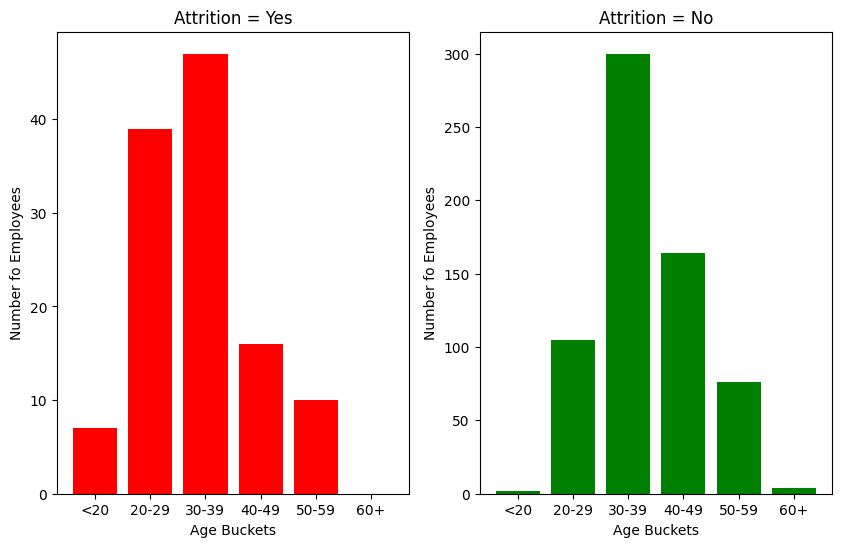

In [25]:
#Call the class
try:
    attrition = Attrition(clean_train_dict)
except Exception as e:
    print(e)

#Get the bins
try:
    yes, no = attrition.distribution_by_age('Attrition')
except Exception as e:
    print(e)

#Print the histogram
try:
    attrition.histogram(yes, no)
except Exception as e:
    print(e)


##### Part 3: Analyzing Attrition Among Employees Based on Job Satisfaction (Pie Chart)

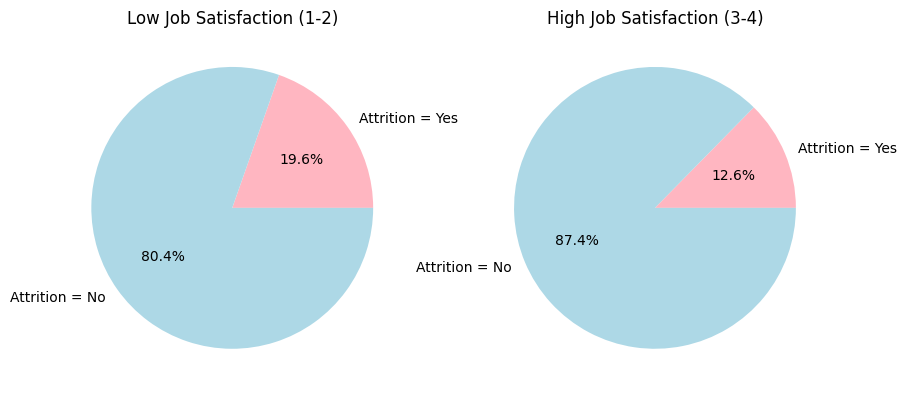

In [26]:
#get the job satisfaction breakdown by attrition
try:
    low_satisfaction, high_satisfaction = attrition.satisfaction('Attrition')
except Exception as e:
    print(e)

#Display the pie charts
try:
    attrition.pie(low_satisfaction, high_satisfaction)
except Exception as e:
    print(e)

##### Part 4: Checking for Class Imbalance in the Training Data

In [27]:

#Display the counts of attrition
try:
    attrition.display_count()
except Exception as e:
    print(e)

Number of Employees who Quit (Attrition=Yes): 119
Number of Employees who Stayed (Attrition=No): 651


## Section B

### CODE:

In [28]:
class DecisionTree:
    """An instance of this class represents a model to predict a value"""

    def __init__(self, train_dict, test_dict):
        if type(train_dict) == dict and type(test_dict) == dict:
            self.train = train_dict
            self.test = test_dict
        else:
            raise Exception('Error: Input Must be a Dictionary')
        
        self._x_train = []
        self._y_train = []

        self._x_test = []
        self._y_test = []
        self._y_pred = []

        self._scaler = StandardScaler()
        self._clf = DecisionTreeClassifier()
        self._accessor = Accessor(self.train)

    def _get_train_rows(self):
        """
        Converts the numerical columns into rows for the training dataset
        Inputs: None
        Returns: list - rows: a list of lists, where each inner list is a row
        """
        cols = {} #A dictionary of each numerical column and its data, which we will be using to convert into rows

        for key, value in self.train.items():
            if key not in CATEGORICAL_COLUMNS:
                cols[key] = value

        rows = self._accessor.convert_to_rows(cols)

        return rows
    
    def _get_test_rows(self):
        """
        Does the same thign as above, but for the test rows
        Inputs: None
        Returns: list - rows: a list of lists, where each inner list is a row
        """
        cols = {} #A dictionary of each numerical column and its data, which we will be using to convert into rows

        for key, value in self.test.items():
            if key not in CATEGORICAL_COLUMNS:
                cols[key] = value

        rows = self._accessor.convert_to_rows(cols)

        return rows

    def _scale_train_rows(self, rows):
        """
        Scales the rows using fit_transform from StandardScaler
        Inputs: list - rows: rows we are scaling
        Returns: list - scaled rows
        """
        if type(rows) == list:
            scaled_data = self._scaler.fit_transform(rows)
            scaled_data = scaled_data.tolist()
            return scaled_data
        else:
            raise Exception('Error: Input must be a list of lists')
    
    def _scale_test_rows(self, rows):
        """
        Does the same thing as above, except it uses the training fit to scale the testing data
        Inputs: list - rows: rows we are scaling
        Returns: list - scaled rows
        """
        if type(rows) == list:
            scaled_data = self._scaler.transform(rows)
            scaled_data = scaled_data.tolist()
            return scaled_data
        else:
            raise Exception('Error: Input must be a list of lists')
    
    def _fill_x_train(self):
        """
        Fills x_train with its corresponding scaled rows
        Inputs: list - scaled rows: A list of lists, where each inner list is a row that has been scaled
        Returns: None (However, it updates _x_train)
        """
        try:
            rows = self._get_train_rows()
            scaled_rows = self._scale_train_rows(rows)

            for row in scaled_rows:
                self._x_train.append(row)
        except Exception as e: 
            raise e

    def _fill_x_test(self):
        """
        Does the same thing as above, but with _x_test
        Inputs: list - scaled rows: A list of lists, where each inner list is a row that has been scaled
        Returns: None (However, it updates _x_train)
        """
        try:
            rows = self._get_test_rows()
            scaled_rows = self._scale_test_rows(rows)

            for row in scaled_rows:
                self._x_test.append(row)
        except Exception as e: 
            raise e
        

    def _fill_y_train(self, col_n):
        """
        Fills the _y_train list with the outcome of the yes/no column chosen (1 for yes, 0 for no)
        Inputs: None
        Returns: None (however, it updates the _y_train list)
        """

        if col_n in self.train.keys():

            for outcome in self.train[col_n]:
                if outcome == 'Yes':
                    self._y_train.append(1)
                elif outcome == 'No':
                    self._y_train.append(0)
                else:
                    raise Exception('Error: Column must be filled with yes or no values')


        else:
            raise Exception('Column does not exist')
        
    def _fill_y_test(self, col_n):
        """
        Does the same thing as above, but for the _y_test list
        Inputs: None
        Returns: None (however, it updates the _y_test list)
        """

        if col_n in self.test.keys():

            for outcome in self.test[col_n]:
                if outcome == 'Yes':
                    self._y_test.append(1)
                elif outcome == 'No':
                    self._y_test.append(0)
                else:
                    raise Exception('Error: Column must be filled with yes or no values')
                    
        else:
            raise Exception('Column does not exist')
        
    def _train_model(self):
        """
        Creates the model using the training data
        Inputs: None
        Returns: None
        """
        if len(self._x_train) == 0 or len(self._y_train) == 0:
            raise Exception('Error: One or more lists is empty')
        else:
            self._clf.fit(self._x_train, self._y_train)

    
    def _predict(self):
        """
        Fills _y_pred with our predicted output from _x_test
        Inputs: None
        Returns: None
        """
        if len(self._x_test) != 0:
            self._y_pred = self._clf.predict(self._x_test)
        else:
            raise Exception('Error: List x_test is empty')
        
    def run_model(self, col_n):
        """
        Uses the above functions to run the model
        Inputs: str - col_n: the column name of the column we are trying to predict
        Returns: None
        """
        try: 
            #Fill the lists we will be using to train the model
            self._fill_x_train()
            self._fill_y_train(col_n)

            #Train the model
            self._train_model()

            #Fill the list we will be using to test the model
            self._fill_x_test()

            #Run the prediction
            self._predict()

        except Exception as e:
            raise e
        
    def display_model(self, col_n):
        """
        Runs the model and displays the results using accuracy score, classification report, and confusion matrix
        Inputs: None
        Returns: None
        """
        try:
            self._fill_y_test(col_n)

            print("Test Accuracy:", round(accuracy_score(self._y_test, self._y_pred), 2))
            print("\nClassification Report:\n", classification_report(self._y_test, self._y_pred))
            print("\nConfusion Matrix:\n", confusion_matrix(self._y_test, self._y_pred))

        except Exception as e:
            raise e
        
    def get_prediction(self):
        """
        Displays the outputed predictions from the model
        Inputs: The column name we are predicting
        Returns: list - A list containing the prediction (either yes or no for each employee)
        """

        prediction = []

        if len(self._y_pred) != 0:
            for value in self._y_pred:
                if value == 1:
                    prediction.append('Yes')
                elif value == 0:
                    prediction.append('No')
                else:
                    raise Exception('Error running the model')
        
            return prediction
        
        else:
            raise Exception('Error: You must run the model first')
        
    def confirm_prediction(self):
        """
        Confirms that the number of employees predicted was the number of employees processed
        Inputs: None
        Returns: 
            int - Number of employees processed
            int - number of employees predicted
        """
        if len(self._x_test) != 0 and len(self._y_pred) != 0:
            return len(self._x_test), len(self._y_pred)
        else:
            raise Exception('Error: You must run the model first')
        
        

### ANSWERS:

In [29]:
 ### RUN AND DISPLAY THE PREDICTION MODEL
# Run the model with train and test
try:
    model1 = DecisionTree(clean_train_dict, clean_test_dict)
    model1.run_model('Attrition') #run the model
    print()
    model1.display_model('Attrition')
except Exception as e:
    print(e)

# Run the model with train and new_employees
try:
    model2 = DecisionTree(clean_train_dict, clean_new_employees)
    model2.run_model('Attrition') #run the model

    #Get the output from prediction
    prediction = model2.get_prediction()
    clean_new_employees['Prediction'] = prediction

except Exception as e:
    print(e)


Test Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       365
           1       0.29      0.29      0.29        76

    accuracy                           0.76       441
   macro avg       0.57      0.57      0.57       441
weighted avg       0.76      0.76      0.76       441


Confusion Matrix:
 [[312  53]
 [ 54  22]]


## Section C

### CODE:

In [ ]:
class Interface:
    """An instance of this class represents the interface for the carousel"""

    def __init__(self, my_dict):
        if type(my_dict) != dict:
            raise Exception('Error: Input must be a dictionary')
        
        self.dict = my_dict
        self.q = Carousel() #Carousel which holds each employee's information
        self.flagged = [] #List of dictionaries to hold each flagged employee's information

    def _prep_carousel(self):
        """
        Prepes the carousel to we can run the display
        Inputs: None
        Returns: None
        """
        
        keys = list(self.dict.keys())

        for i in range(len(self.dict[keys[0]])):
            employee = {} #A dictionary for each employee
            for key, value in self.dict.items():
                employee[key] = value[i]
            self.q.add(employee)
        

    def _store_flagged(self, employee):
        """
        Stores the flagged employees
        Inputs: dict: employee - the employee we are flagging
        Returns: None
        """
        if type(employee) != dict:
            raise Exception('Error: Employee data must be stored in a dictionary')
        if employee not in self.flagged:
            self.flagged.append(employee)
        else:
            print('Employee already exists in the list')

    def display_flagged(self):
        """
        Displays the flagged employees
        Inputs: None
        Returns: None
        """
        if len(self.flagged) == 0:
            print('There are no flagged employees')

        else:
            #Print the initial message
            border = '-' * 50
            print(f'{border}\nFLAGGED EMPLOYEES FOR RETENTION PLANNING\n{border}')

            #Print each employee's name and their prediction
            for i, employee in enumerate(self.flagged):
                try:
                    name = employee['EmployeeName']
                    prediction = employee['Prediction']
                except KeyError:
                    raise Exception('Error: You must have the name of the employee and prediction in the dictionary')
                print(f'{i + 1}. {name} - Prediction: {prediction}')

            print(border)
        print()
        print('Enter 1 for Next; 2 for Previous; 3 to Flag; 4 to Switch View; 0 to Quit')
            
        

    def display_employee(self, employee):
        """
        This function uses a carousel to display employees one at a time
        Inputs: dict - my_dict: a dictionary that holds the information about each employee
        Returns: None
        """
        if type(employee) != dict:
            raise Exception("Error: Input must be a dictionary")
        if 'EmployeeName' not in employee:
            raise Exception("Error: Column 'Employee Name' must be in the dictionary")
        if 'Prediction' not in employee:
            raise Exception("Error: Column 'Prediction' must be in the dictionary")
        
        border = '-' * 50
        name = employee['EmployeeName']
        prediction = employee['Prediction']

        #Display top header
        print(f'{border}\nEmployee Name: {name}\n{border}')

        #Print employee data
        for key, value in employee.items():
            if key != 'EmployeeName' and key != 'Prediction':
                print(f'\t{key}: {value}')
        
        #Print the prediction
        print(border)
        print(f'Prediction (Likely to Quit): {prediction}')
        if prediction == 'Yes':
            print('Recommend: Flag for Retention')
        elif prediction == 'No':
            print('Recommend: No Action Needed')
        print(border)
        print()
        print('Enter 1 for Next; 2 for Previous; 3 to Flag; 4 to Switch View; 0 to Quit')

    def run_display(self):
        """
        Allows for user input to run the display
        Inputs: dict - clean_new_employees: The dict we are performing the display on
        Returns: None
        """
        try:
            #Load the data into the carousel
            self._prep_carousel()

            view = 'carousel' # set the initial view to the carousel, not the list of flagged employees
            keep_going = True

            while keep_going:
                
                if view == "carousel":
                    current_employee = self.q.get_current_data()
                    self.display_employee(current_employee)
                else:
                    self.display_flagged()

                choice = input().strip()


                while choice not in ['0','1','2','3','4']:
                    clear_output(wait=True)
                    if view == "carousel":
                        current_employee = self.q.get_current_data()
                        self.display_employee(current_employee)
                    else:
                        self.display_flagged()
                    print("Invalid input.")
                    choice = input().strip()
                
                clear_output(wait=True)

                if choice == '1':
                    if view == "carousel":
                        self.q.move_next()

                elif choice == '2':
                    if view == "carousel":
                        self.q.move_previous()

                elif choice == '3':
                    if view == "carousel":
                        self._store_flagged(current_employee)

                elif choice == '4':
                    if view == "carousel":
                        view = "flagged"  
                    else:
                        view = "carousel"

                elif choice == '0':
                    keep_going = False

        except Exception as e:
            print(e)


### ANSWERS:

##### Part 1: Prediction

In [31]:
try:  
    #Print the confirmation
    processed, predicted = model2.confirm_prediction()
    print()
    print(f'Processed {processed} employees\nGenerated {predicted} Predictions')
except Exception as e:
    print(e)


Processed 9 employees
Generated 9 Predictions


##### Part 2: Circular Doubly-Linked List

*See carousel.py*

##### Part 3: Interface

In [32]:
try: 
    interface = Interface(clean_new_employees)
    interface.run_display()
except Exception as e:
    print(e)

--------------------------------------------------
FLAGGED EMPLOYEES FOR RETENTION PLANNING
--------------------------------------------------
1. Amanda Taylor - Prediction: Yes
2. David Brown - Prediction: No
--------------------------------------------------

Enter 1 for Next; 2 for Previous; 3 to Flag; 4 to Switch View; 0 to Quit
